# Park Access Equity Analysis - San Antonio

Analyzes which Bexar County block groups have adequate park access using a 0.5-mile walking distance buffer. Census ACS 2020 demographic data is joined to TIGER shapefiles and overlaid with City of San Antonio park boundaries to estimate the share of residents within walking distance of a park, broken out by income quartile and population density.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import censusdata
import os
from dotenv import load_dotenv

In [2]:
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data
### 2a. Park Boundaries (City of San Antonio GIS)

In [3]:
gdf = gpd.read_file(r'Park_Boundaries\Park_Boundaries.shp')

### 2b. Park Boundary Exploration

In [4]:
gdf.columns.tolist()

['ParkID',
 'ParkName',
 'AltParkNam',
 'StreetNumb',
 'StreetName',
 'ParkType',
 'geometry']

In [5]:
# NAD 1983 StatePlane Texas South Central (US survey foot)
# Projected crs, coordinates in feet
gdf.crs

<Projected CRS: EPSG:2278>
Name: NAD83 / Texas South Central (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Texas - counties of Aransas; Atascosa; Austin; Bandera; Bee; Bexar; Brazoria; Brewster; Caldwell; Calhoun; Chambers; Colorado; Comal; De Witt; Dimmit; Edwards; Fayette; Fort Bend; Frio; Galveston; Goliad; Gonzales; Guadalupe; Harris; Hays; Jackson; Jefferson; Karnes; Kendall; Kerr; Kinney; La Salle; Lavaca; Live Oak; Matagorda; Maverick; McMullen; Medina; Presidio; Real; Refugio; Terrell; Uvalde; Val Verde; Victoria; Waller; Wharton; Wilson; Zavala.
- bounds: (-105.0, 27.78, -93.76, 30.67)
Coordinate Operation:
- name: SPCS83 Texas South Central zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

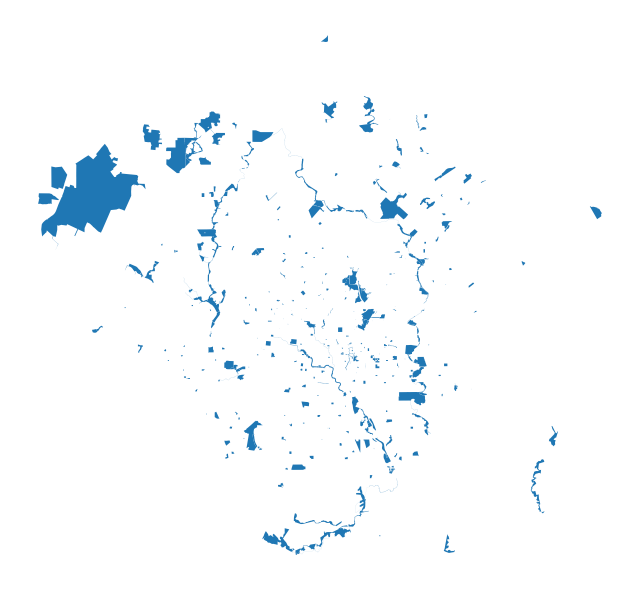

In [6]:
fig, ax = plt.subplots(figsize=(8,8))
gdf.plot(ax=ax)
ax.set_axis_off()
plt.show()

In [7]:
gdf.head()

,ParkID,ParkName,AltParkNam,StreetNumb,StreetName,ParkType,geometry
0,400,Shadwell Park,NaN,1135,Shadwell,Neighborhood Park,"POLYGON ((2108039.4 13719060.74, 2108039.8 137..."
1,401,Brooks Greenline Park,NaN,2532,Sidney Brooks,Neighborhood Park,"POLYGON ((2143881.411 13675770.99, 2143923.555..."
2,402,North San Antonio Hills Park,NaN,3222,Shimmering Dawn,Neighborhood Park,"POLYGON ((2056632.576 13717802.357, 2056304.45..."
3,407,Pipers Meadow Park,NaN,7403,Joe Newton,NaN,"POLYGON ((2084502.863 13717100.859, 2084280.50..."
4,408,Barbara Drive Park,Skipper Park,210,Barbara Dr.,Neighborhood Park,"MULTIPOLYGON (((2130396.776 13730688.918, 2130..."


In [8]:
gdf.nunique()

ParkID        337
ParkName      337
AltParkNam    265
StreetNumb    282
StreetName    289
ParkType       10
geometry      337
dtype: int64

In [9]:
gdf['ParkType'].unique()

<StringArray>
[   'Neighborhood Park',                    nan,       'Community Park',
     'Large Urban Park',             'Greenway', 'Special Use Facility',
    'Historic Resource',         'Natural Area',       'Sports Complex',
  'Historical Facility',          'Urban Space']
Length: 11, dtype: str

### 2c. Census ACS Data (Bexar County Block Groups)

In [10]:
# Load Census API key from env
load_dotenv()
CENSUS_KEY = os.getenv("CENSUS_API_KEY")

In [11]:
# Texas, bexar county, variable
bexarbg = censusdata.download('acs5', 2020,
                          censusdata.censusgeo([('state', '48'), ('county', '029'), ('block group', '*')]),
                          ['B01003_001E', 'B19013_001E', 'B01002_001E'],
                              key=CENSUS_KEY
                              )

bexarbg = bexarbg.rename(columns={'B01003_001E': 'total_population', 'B19013_001E': 'median_hh_income', 'B01002_001E': 'median_age'})

### 2d. Census Data Exploration

In [12]:
bexarbg.head()

,total_population,median_hh_income,median_age
"Block Group 3, Census Tract 1103, Bexar County, Texas: Summary level: 150, state:48> county:029> tract:110300> block group:3",777,65121,37.5
"Block Group 2, Census Tract 1106, Bexar County, Texas: Summary level: 150, state:48> county:029> tract:110600> block group:2",1556,16161,51.0
"Block Group 1, Census Tract 1110, Bexar County, Texas: Summary level: 150, state:48> county:029> tract:111000> block group:1",833,21071,33.4
"Block Group 3, Census Tract 1110, Bexar County, Texas: Summary level: 150, state:48> county:029> tract:111000> block group:3",1046,60735,28.8
"Block Group 3, Census Tract 1111, Bexar County, Texas: Summary level: 150, state:48> county:029> tract:111100> block group:3",643,42031,32.7


In [13]:
bexarbg.columns.tolist()

['total_population', 'median_hh_income', 'median_age']

In [14]:
print(f"Total Population: {bexarbg['total_population'].sum()}")

Total Population: 1978826


### 2e. TIGER Block Group Shapefiles

In [15]:
tiger = gpd.read_file(r'tl_2023_48_bg\tl_2023_48_bg.shp')

In [16]:
# Filter to Bexar County
tiger = tiger[tiger['COUNTYFP'] == '029']

In [17]:
tiger.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,GEOIDFQ,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
807,48,029,182003,1,480291820031,1500000US480291820031,Block Group 1,G5030,S,5939086,3937,+29.5952357,-098.6387277,"POLYGON ((-98.65262 29.59343, -98.65256 29.594..."
1139,48,029,121606,3,480291216063,1500000US480291216063,Block Group 3,G5030,S,586667,0,+29.5529878,-098.3363136,"POLYGON ((-98.3413 29.55396, -98.34046 29.5543..."
1140,48,029,121604,2,480291216042,1500000US480291216042,Block Group 2,G5030,S,1509863,7297,+29.5299609,-098.3136329,"POLYGON ((-98.32862 29.53726, -98.32856 29.537..."
1141,48,029,121604,3,480291216043,1500000US480291216043,Block Group 3,G5030,S,401071,0,+29.5221084,-098.3162503,"POLYGON ((-98.3208 29.52366, -98.32001 29.5241..."
1142,48,029,121604,4,480291216044,1500000US480291216044,Block Group 4,G5030,S,1089643,0,+29.5296825,-098.3210263,"POLYGON ((-98.33052 29.53562, -98.33007 29.535..."


In [18]:
tiger.columns.tolist()

['STATEFP',
 'COUNTYFP',
 'TRACTCE',
 'BLKGRPCE',
 'GEOID',
 'GEOIDFQ',
 'NAMELSAD',
 'MTFCC',
 'FUNCSTAT',
 'ALAND',
 'AWATER',
 'INTPTLAT',
 'INTPTLON',
 'geometry']

In [19]:
tiger.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

## 3. Merge Census Data to TIGER Geometries

Extract state/county/tract/block group codes from the Census index, build a 12-digit GEOID, and join to TIGER boundaries.

In [20]:
# Extract geo data from index in order to join on tiger data for geometries
geo_data = []

for geo in bexarbg.index:
    geo_dict = dict(geo.geo) # converts list of tuples to dict
    geo_data.append({
        "state": geo_dict.get("state"),
        "county":geo_dict.get("county"),
        "tract": geo_dict.get("tract"),
        "block_group": geo_dict.get("block group"),
    })

geo_df = pd.DataFrame(geo_data)


bexarbg = bexarbg.reset_index(drop=True).join(geo_df)

# ensure padding and join to create 12 digit geoid
bexarbg['state'] = bexarbg['state'].str.zfill(2)
bexarbg['county'] = bexarbg['county'].str.zfill(3)
bexarbg['tract'] = bexarbg['tract'].str.zfill(6)
bexarbg['block_group'] = bexarbg['block_group'].str.zfill(1)

bexarbg['GEOID'] = (
    bexarbg['state'] +
    bexarbg['county'] +
    bexarbg['tract'] +
    bexarbg['block_group']
)

# TIGER is already padded, create geoid
tiger['GEOID'] = (
    tiger['STATEFP'] +
    tiger['COUNTYFP'] +
    tiger['TRACTCE'] +
    tiger['BLKGRPCE']
)

### 3a. Merge and Reproject

Merge Census attributes onto TIGER geometries and reproject to EPSG:2278 (NAD83 Texas South Central, survey feet) to match park boundary CRS.

In [21]:
merged = tiger.merge(bexarbg, on='GEOID', how='left')
# Need to reproject tiger
merged = merged.to_crs("EPSG:2278")

In [22]:
merged.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,GEOIDFQ,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,INTPTLAT,INTPTLON,geometry,total_population,median_hh_income,median_age,state,county,tract,block_group
0,48,029,182003,1,480291820031,1500000US480291820031,Block Group 1,G5030,S,5939086,...,+29.5952357,-098.6387277,"POLYGON ((2078894.761 13763475.12, 2078912.996...",3886,128605,41.1,48,029,182003,1
1,48,029,121606,3,480291216063,1500000US480291216063,Block Group 3,G5030,S,586667,...,+29.5529878,-098.3363136,"POLYGON ((2177912.338 13749548.524, 2178177.60...",1213,61637,33.1,48,029,121606,3
2,48,029,121604,2,480291216042,1500000US480291216042,Block Group 2,G5030,S,1509863,...,+29.5299609,-098.3136329,"POLYGON ((2181979.956 13743498.44, 2181996.687...",1893,93846,35.8,48,029,121604,2
3,48,029,121604,3,480291216043,1500000US480291216043,Block Group 3,G5030,S,401071,...,+29.5221084,-098.3162503,"POLYGON ((2184493.266 13738568.071, 2184744.95...",529,37464,38.7,48,029,121604,3
4,48,029,121604,4,480291216044,1500000US480291216044,Block Group 4,G5030,S,1089643,...,+29.5296825,-098.3210263,"POLYGON ((2181379.234 13742898.294, 2181521.37...",2538,47465,34.9,48,029,121604,4


## 4. Park Access Buffer Analysis

Creates a 0.5-mile (2,640 survey foot) buffer around all parks, dissolves overlapping buffers into a single access zone, then calculates what share of each block group's area — and estimated population — falls within walking distance.

In [23]:
# Create .5 mile buffer = 2,640 survey feet
# Deduplicate census data - keep one row per block group
blocks_unique = merged.drop_duplicates(subset='GEOID').copy()

# Create 0.5 mile (2,640 ft) buffer around parks
park_buffers = gdf.copy()
park_buffers.geometry = park_buffers.buffer(2640)

# Dissolve overlapping buffers into single access zone
park_access_zone = park_buffers.dissolve()

# Calculate total area of each block group
blocks_unique['total_area'] = blocks_unique.geometry.area

# Find which parts of block groups fall within park access zone
blocks_in_access_zone = gpd.overlay(blocks_unique, park_access_zone, how='intersection')

# Calculate area within access zone
blocks_in_access_zone['area_with_access'] = blocks_in_access_zone.geometry.area

# Sum up access area per block group (handles fragmented geometries)
access_by_block = (
    blocks_in_access_zone
    .groupby('GEOID')['area_with_access']
    .sum()
    .reset_index()
)

# Merge back to blocks, filling 0 for blocks with no park access
blocks_gdf = blocks_unique.merge(access_by_block, on='GEOID', how='left')
blocks_gdf['area_with_access'] = blocks_gdf['area_with_access'].fillna(0)

# Calculate percentage of block group within walking distance of park
blocks_gdf['pct_park_access'] = blocks_gdf['area_with_access'] / blocks_gdf['total_area']

# Cap at 100% (handles geometric artifacts from overlay)
blocks_gdf['pct_park_access'] = blocks_gdf['pct_park_access'].clip(upper=1.0)

# Calculate population with park access
blocks_gdf['pop_with_access'] = blocks_gdf['pct_park_access'] * blocks_gdf['total_population']

print(f"Blocks analyzed: {len(blocks_gdf)}")
print(blocks_gdf['pct_park_access'].describe())

Blocks analyzed: 1139
count    1139.000000
mean        0.603465
std         0.406753
min         0.000000
25%         0.139914
50%         0.757239
75%         1.000000
max         1.000000
Name: pct_park_access, dtype: float64


## 5. Access Summary Statistics

In [24]:
# How many ppl out of the population have good access to parks
print(blocks_gdf['pop_with_access'].sum())
print(merged['total_population'].sum())
pct_of_total = blocks_gdf['pop_with_access'].sum() / merged['total_population'].sum()
print(pct_of_total)

1094664.2787052374
1978826
0.5531887486344113


In [25]:
# income quartiles and park access
blocks_gdf['income_quartile'] = pd.qcut(blocks_gdf['median_hh_income'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
print(blocks_gdf.groupby('income_quartile')['pct_park_access'].mean())

income_quartile
Q1    0.778303
Q2    0.700946
Q3    0.531549
Q4    0.402811
Name: pct_park_access, dtype: float64


## 6. Road Context Layer (Loop 410 / Loop 1604)

Loads primary/secondary roads and filters to the two major San Antonio loops for use as reference boundaries in the choropleth map.

In [26]:
roads = gpd.read_file(r'tl_2019_48_prisecroads\tl_2019_48_prisecroads.shp')

# Check what column has the road names/types
print(roads.columns)
print(roads['FULLNAME'].value_counts().head(20))

Index(['LINEARID', 'FULLNAME', 'RTTYP', 'MTFCC', 'geometry'], dtype='str')
FULLNAME
US Hwy 87      166
US Hwy 287     164
US Hwy 59      155
US Hwy 82      115
Main St        112
US Hwy 90      108
US Hwy 77      107
US Hwy 281     104
US Hwy 83      101
N Main St      100
US Hwy 84       99
US Hwy 67       96
US Hwy 69       90
US Hwy 277      89
State Hwy 6     88
US Hwy 190      86
US Hwy 377      85
US Hwy 62       81
S Main St       80
W Main St       77
Name: count, dtype: int64


In [27]:
# Filter to just the loops
loops = roads[roads['FULLNAME'].str.contains('Loop 410|Loop 1604', case=False, na=False)]

# Or if they're labeled differently, check for:
# - Interstate/Loop route numbers
# - RTTYP (route type) column
print(loops[['FULLNAME', 'RTTYP']].drop_duplicates())

             FULLNAME RTTYP
778     E Loop 1604 N     M
787     W Loop 1604 N     M
1017    E Loop 1604 S     M
1236    S Loop 1604 E     M
1444    S Loop 1604 W     M
5465  State Loop 1604     S


In [28]:
# Look for 410
loop_410 = roads[roads['FULLNAME'].str.contains('410', case=False, na=False)]
print(loop_410[['FULLNAME', 'RTTYP']].drop_duplicates())

      FULLNAME RTTYP
5466    I- 410     I
12479  FM 2410     O


In [29]:
# Get both loops
loops = roads[
    roads['FULLNAME'].str.contains('Loop 1604|I- 410', case=False, na=False)
].copy()

# Reproject to match your map
loops = loops.to_crs('EPSG:3857')

# Clip to Bexar County area to reduce size (optional but faster)
loops = loops.cx[
    blocks_gdf.to_crs('EPSG:3857').total_bounds[0]:blocks_gdf.to_crs('EPSG:3857').total_bounds[2],
    blocks_gdf.to_crs('EPSG:3857').total_bounds[1]:blocks_gdf.to_crs('EPSG:3857').total_bounds[3]
]

print(f"Loop segments: {len(loops)}")

Loop segments: 23


## 7. Visualizations

### 7a. Park Access with Road Overlays

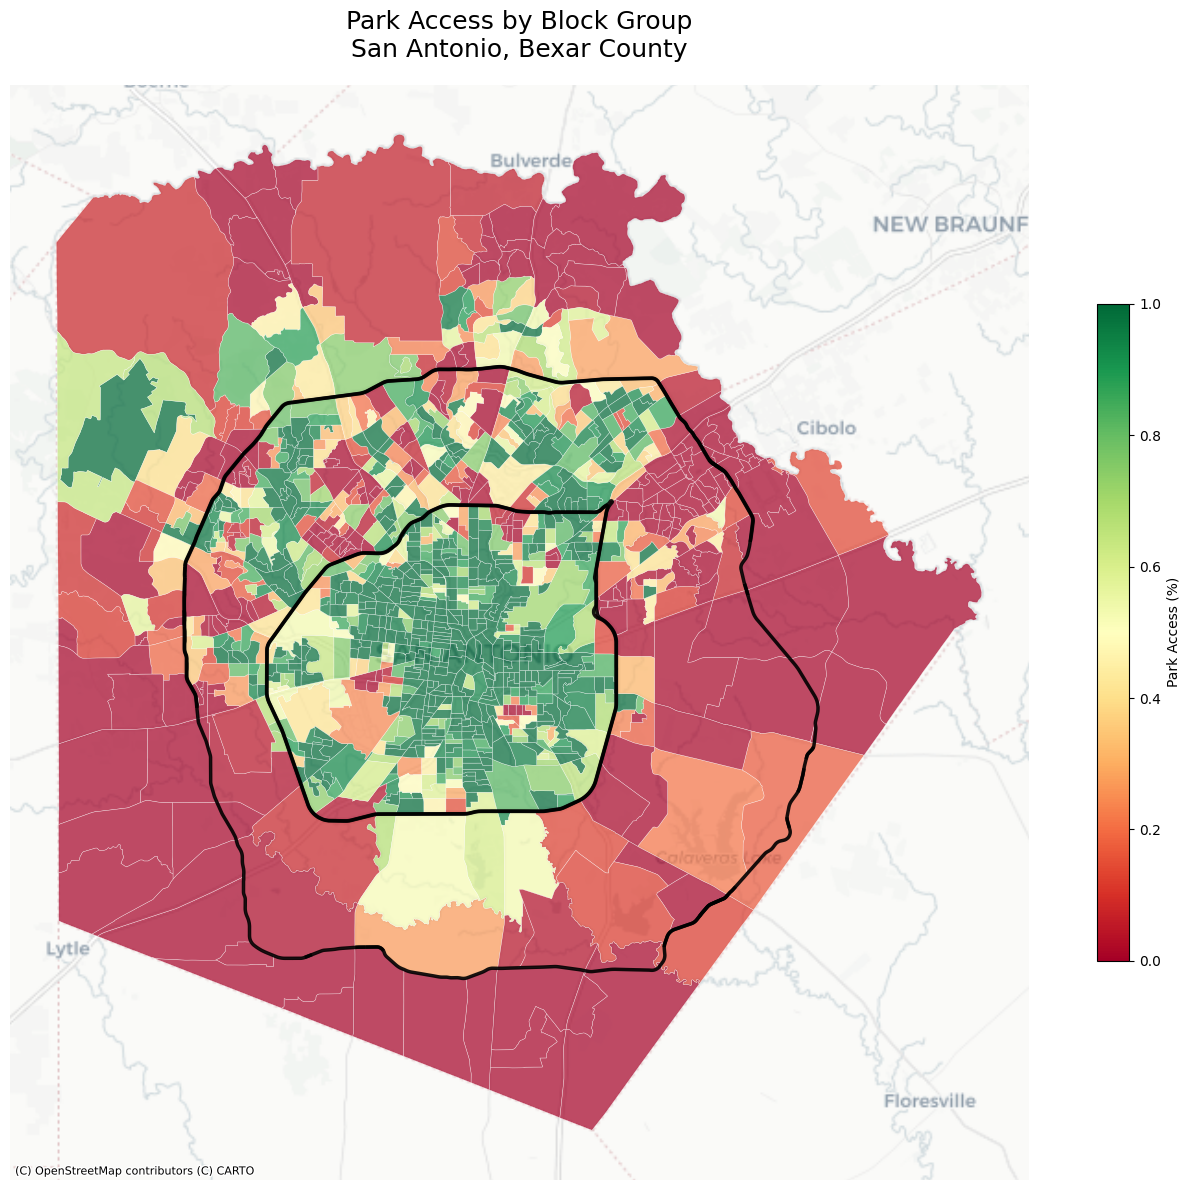

In [30]:
import contextily as ctx

fig, ax = plt.subplots(figsize=(14, 12))

# Reproject to Web Mercator for basemap
blocks_web = blocks_gdf.to_crs(epsg=3857)
loops_web = loops.to_crs(epsg=3857)

# Your choropleth
blocks_web.plot(
    column='pct_park_access',
    ax=ax,
    cmap='RdYlGn',
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    vmin=0,
    vmax=1,
    alpha=0.7,
    legend_kwds={'label': 'Park Access (%)', 'shrink': 0.6}
)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Add highway loops - make them prominent
loops_web.plot(ax=ax, color='black', linewidth=2.5, alpha=0.9, linestyle='-')

ax.set_axis_off()
ax.set_title('Park Access by Block Group\nSan Antonio, Bexar County',
             fontsize=18, pad=20)

plt.tight_layout()
plt.savefig('park_access_map_with_highways.png', dpi=300, bbox_inches='tight')
plt.show()

### 7b. Population Density

In [31]:
# Calculate population density (people per square mile)
blocks_gdf['pop_density'] = blocks_gdf['total_population'] / (blocks_gdf['total_area'] / 27878400)

# Check the distribution to pick a good threshold
print(blocks_gdf['pop_density'].describe())
print(f"\nBlocks with density > 500: {(blocks_gdf['pop_density'] > 500).sum()}")
print(f"Blocks with density > 1000: {(blocks_gdf['pop_density'] > 1000).sum()}")

# Split urban vs rural
urban_blocks = blocks_gdf[blocks_gdf['pop_density'] > 1000].copy()
rural_blocks = blocks_gdf[blocks_gdf['pop_density'] <= 1000].copy()

print(f"Urban blocks analyzed: {len(urban_blocks)}")
print(f"Rural blocks (grayed out): {len(rural_blocks)}")

# Rest of the plotting code stays the same...

# Reproject for mapping
urban_web = urban_blocks.to_crs(epsg=3857)
rural_web = rural_blocks.to_crs(epsg=3857)
loops_web = loops.to_crs(epsg=3857)



count     1139.000000
mean      5301.429488
std       3540.155082
min          0.000000
25%       2663.243875
50%       4914.605290
75%       7103.744645
max      22726.251073
Name: pop_density, dtype: float64

Blocks with density > 500: 1078
Blocks with density > 1000: 1040
Urban blocks analyzed: 1040
Rural blocks (grayed out): 99


### 7c. Choropleth — Park Access by Block Group

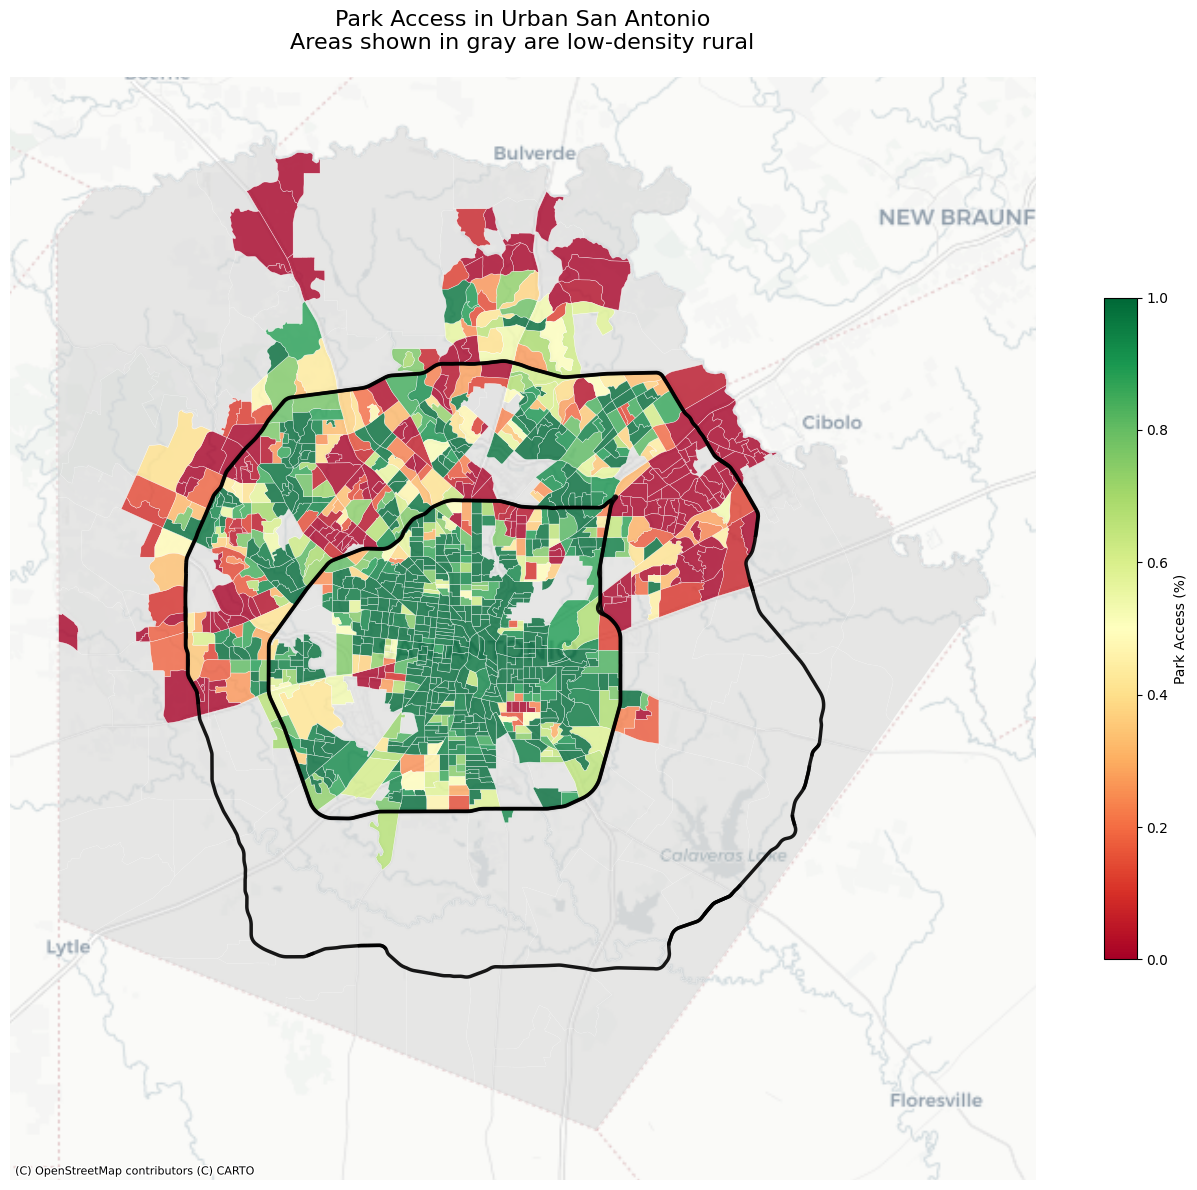

In [32]:
# Create map
fig, ax = plt.subplots(figsize=(14, 12))

# Plot rural blocks in gray
rural_web.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.2, alpha=0.5)

# Plot urban blocks with your analysis
urban_web.plot(
    column='pct_park_access',
    ax=ax,
    cmap='RdYlGn',
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    vmin=0,
    vmax=1,
    alpha=0.8,
    legend_kwds={'label': 'Park Access (%)', 'shrink': 0.6}
)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Add highways
loops_web.plot(ax=ax, color='black', linewidth=2.5, alpha=0.9)

ax.set_axis_off()
ax.set_title('Park Access in Urban San Antonio\nAreas shown in gray are low-density rural',
             fontsize=16, pad=20)

plt.tight_layout()
plt.savefig('park_access_urban_focus.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Export

Uncomment to save block group GeoJSON for use in a Leaflet map.

In [33]:
# blocks_gdf.to_file("neighborhoods.geojson", driver="GeoJSON")